
# Lab 2
**Dataset:** `stats_case_study_dataset_v5.csv` (download provided)  
**Topics (only these):**
- Percentiles & Quartiles (Q1, Q2/Median, Q3), IQR, Box plot interpretation, Outliers (IQR rule)
- Histogram, Bar, Pie, Frequency tables, KDE
- Distribution shapes (normal/skewed), modality, visual outliers
- Scatter plots, Covariance & Pearson Correlation, Positive/Negative/No correlation, Correlation ≠ Causation
- Cross-tabulations and **stacked bar charts**; Numeric vs categorical bivariate analysis

**Instructions:** Each exercise is in markdown followed by an empty code cell.  
Write any brief explanations as comments right inside your code cell.


## Setup (optional)

# Percentiles, Quartiles, IQR, Box Plots, Outliers

**Exercise 1:** Load the dataset from `stats_case_study_dataset_v5.csv` into `df`. Inspect `df.head(3)` and list numeric columns you will use for this section (e.g., `salary`, `monthly_sales`, `years_experience`).

In [4]:
import pandas as pd

df = pd.read_csv(r"C:\Users\mishr\Statistics\stats_case_study_dataset_v5 (1).csv")
df.head(3)
df_numeric = df.select_dtypes(include='number')
df_numeric.head(3)

,id,years_experience,age,is_manager,work_hours_per_week,performance_rating,salary,monthly_sales
0,1,5.4,39,0,40.0,2,73527.0,0.0
1,2,2.1,40,0,47.7,3,45774.0,7353.0
2,3,16.8,41,0,41.7,3,103869.0,6505.0


**Exercise 2:** Compute the 25th, 50th (median), and 75th percentiles for `salary` and interpret one sentence for what the **75th percentile** means.

In [5]:
q1 = df['salary'].quantile(0.25)
q2 = df['salary'].quantile(0.50)
q3 = df['salary'].quantile(0.75)

print(q1)
print(q2)
print(q3)

51286.5
60493.5
76023.75


**Exercise 3:** Compute **IQR** for `salary` and identify **outlier cutoffs** using 1.5×IQR rule. Report the lower and upper bounds.

In [6]:
iqr = q3 - q1
print(iqr)

24737.25


In [7]:
lower_bound = q1 - 1.5*(iqr)
upper_bound = q3 + 1.5*(iqr)
print(lower_bound)
print(upper_bound)

14180.625
113129.625


**Exercise 4:** Using the bounds above, compute how many outliers are in `salary` (below lower or above upper). Then filter a non-outlier subset `df_no_out` for further comparison.

In [8]:
outliers = df[(df['salary'] < lower_bound) | (df['salary'] > upper_bound)]
outliers

,id,department,region,gender,education_level,years_experience,age,is_manager,work_hours_per_week,performance_rating,salary,monthly_sales
76,77,Finance,West,Male,High School,4.3,32,0,39.5,4,197625.0,7002.0
93,94,Tech,South,Female,Bachelors,3.6,24,0,32.2,3,213957.0,2213.0
150,151,Operations,North,Female,High School,6.9,39,0,48.8,3,131616.0,1459.0


In [10]:
df_no_out = df[(df['salary'] >= lower_bound) & (df['salary'] <= upper_bound)]
df_no_out

,id,department,region,gender,education_level,years_experience,age,is_manager,work_hours_per_week,performance_rating,salary,monthly_sales
0,1,Tech,West,Male,Bachelors,5.4,39,0,40.0,2,73527.0,0.0
1,2,Operations,South,Female,Bachelors,2.1,40,0,47.7,3,45774.0,7353.0
2,3,Finance,North,Male,Bachelors,16.8,41,0,41.7,3,103869.0,6505.0
3,4,Tech,South,Male,High School,6.7,36,0,39.5,5,75929.0,4232.0
4,5,Sales,North,Female,High School,6.6,31,0,38.2,3,50906.0,24137.0
...,...,...,...,...,...,...,...,...,...,...,...,...
235,236,Finance,West,Male,Bachelors,5.1,27,0,43.3,3,60671.0,9245.0
236,237,Sales,East,Female,Masters,8.9,32,0,34.0,3,47279.0,21924.0
237,238,Sales,West,Male,Bachelors,10.9,34,0,38.6,4,53924.0,24338.0
238,239,HR,West,Male,Bachelors,9.8,34,0,44.6,3,54213.0,14406.0


**Exercise 5:** Create a **box plot** for `salary` and (separately) for `monthly_sales` using pandas/Matplotlib. Based on the plot, comment on any skew/outliers you observe.

<Axes: title={'center': 'Box Plot for Salary'}>

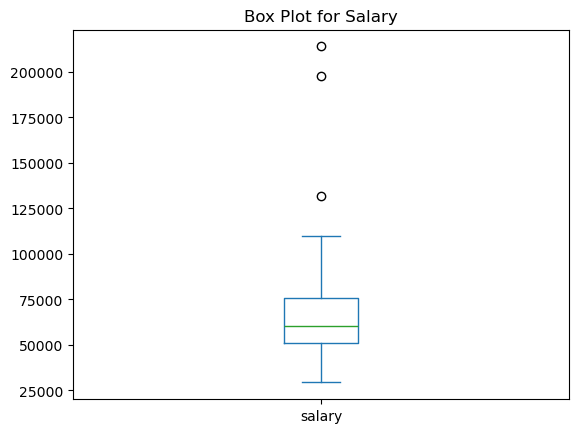

In [11]:
df['salary'].plot(kind='box', title = 'Box Plot for Salary')

**Exercise 6:** Compute the **90th percentile** for `monthly_sales` and interpret it in one line.

In [12]:
df['monthly_sales'].quantile(0.90)

np.float64(24424.6)

# Hist/Bar/Pie, Frequency Tables, KDE

**Exercise 1:** Plot a **histogram** of `salary` with 25 bins. Add axis labels and a title.

<Axes: title={'center': 'Salary Plot'}, xlabel='Salary', ylabel='Count'>

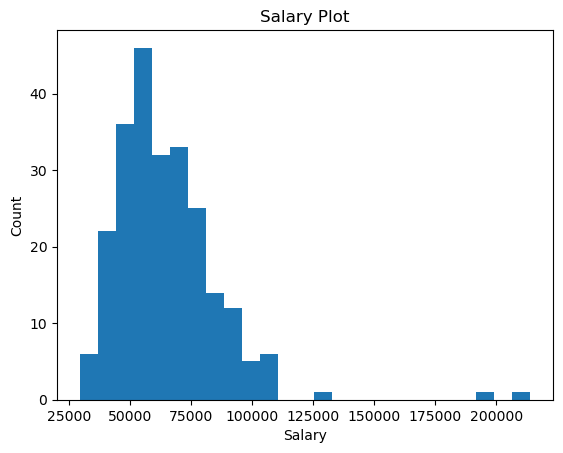

In [34]:
df['salary'].plot(kind='hist', bins=25, xlabel='Salary', ylabel='Count', title='Salary Plot')

**Exercise 2:** Create a **frequency distribution table** for `salary` using 5 equal-width bins via `pd.cut`, and display counts per bin.

In [35]:
pd.cut(df['salary'], bins=5).value_counts().reset_index()

,salary,count
0,"(29147.375, 66257.0]",142
1,"(66257.0, 103182.0]",89
2,"(103182.0, 140107.0]",7
3,"(177032.0, 213957.0]",2
4,"(140107.0, 177032.0]",0


**Exercise 3:** Plot a **KDE** (Kernel Density Estimation) curve for `salary`.

<Axes: xlabel='salary', ylabel='Density'>

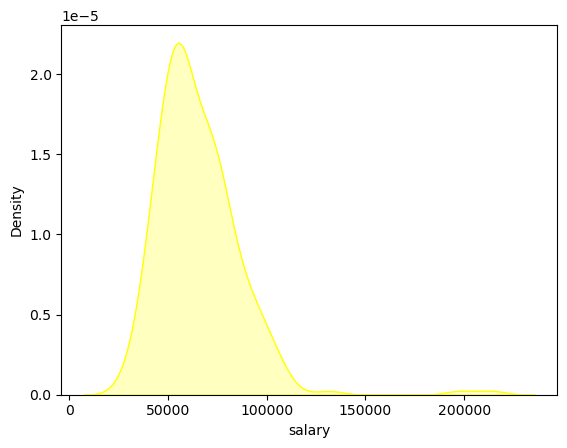

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(df['salary'], fill=True, color='yellow')

**Exercise 4:** Make a **bar chart** of counts by `department` and a **pie chart** of the same distribution.

<Axes: xlabel='department'>

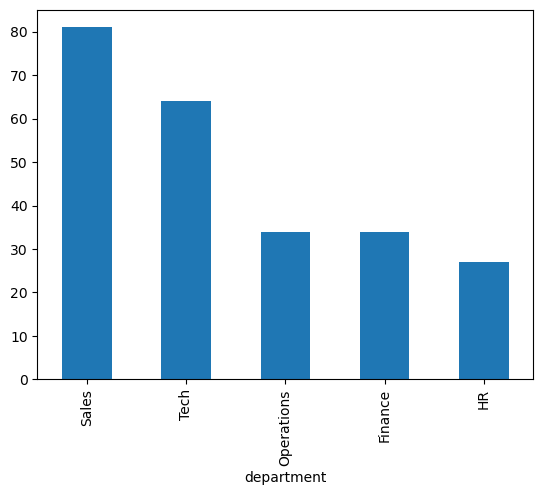

In [37]:
df['department'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

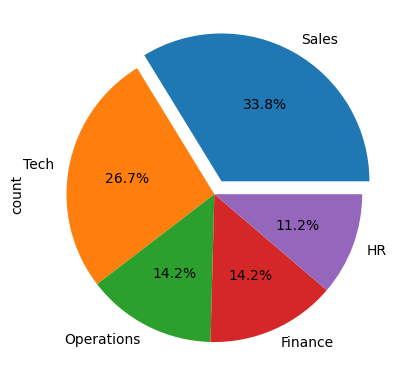

In [42]:
df['department'].value_counts().plot(kind='pie', autopct='%0.1f%%', explode=[0.1,0,0,0,0])

# Distribution Shapes, Modality, Visual Outliers

**Exercise 1:** Using `salary`, comment whether it appears **normal or skewed** by comparing histogram + KDE. Also compute **skewness** with `df['salary'].skew()`.

<Axes: xlabel='salary', ylabel='Count'>

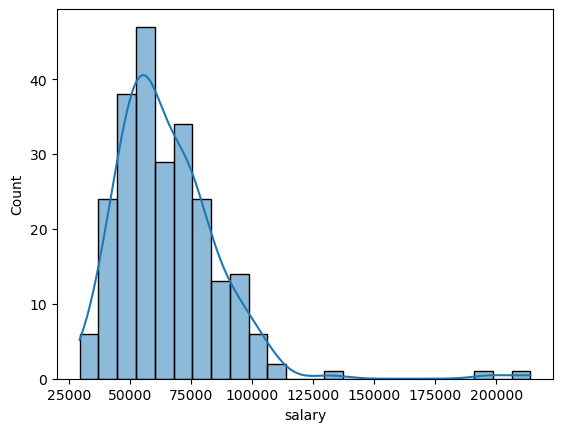

In [48]:
sns.histplot(df['salary'], kde=True)

In [49]:
df['salary'].skew()

np.float64(2.520830170322401)

***Skewness is > 0, so this is Right-Skewed.***

**Exercise 2:** Check **modality** visually: for `monthly_sales`, plot histogram (30 bins) + KDE and briefly note if it looks uni- or multi-modal.

<Axes: xlabel='monthly_sales', ylabel='Count'>

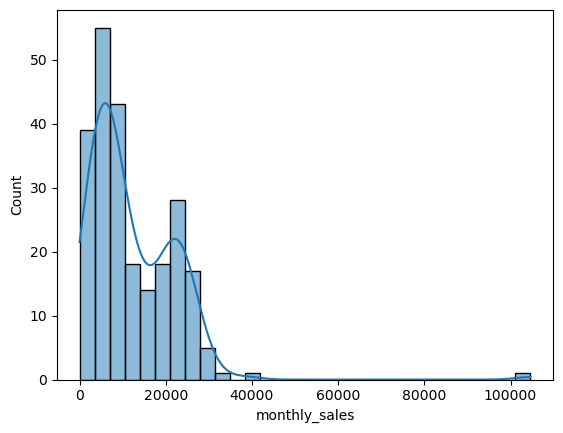

In [43]:
sns.histplot(df['monthly_sales'], bins=30, kde=True)

***We have two peaks here, so this is Bimodal.***

**Exercise 3:** Identify any **visual outliers** in `years_experience` using a box plot and print the suspected outlier values using IQR logic.

<Axes: >

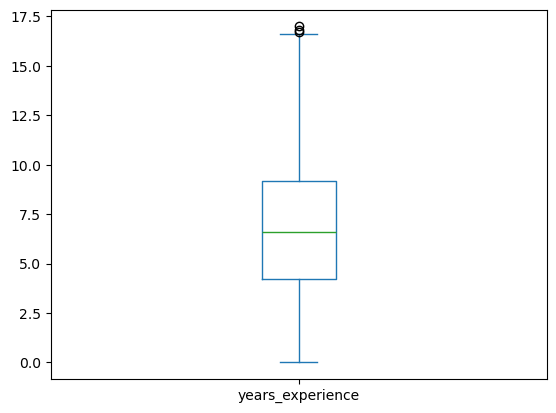

In [45]:
df['years_experience'].plot(kind='box')

In [46]:
q1 = df['years_experience'].quantile(0.25)
q3 = df['years_experience'].quantile(0.75)

iqr = q3 - q1
lower_bound = q1 - 1.5*(iqr)
upper_bound = q3 + 1.5*(iqr)

outliers = df[(df['years_experience'] < lower_bound) | (df['years_experience'] > upper_bound)]
outliers

,id,department,region,gender,education_level,years_experience,age,is_manager,work_hours_per_week,performance_rating,salary,monthly_sales
2,3,Finance,North,Male,Bachelors,16.8,41,0,41.7,3,103869.0,6505.0
103,104,Tech,South,Male,High School,17.0,30,0,42.3,3,103920.0,9054.0
110,111,Sales,North,Male,Masters,16.7,32,0,41.8,4,72522.0,24963.0


# Scatter, Covariance & Pearson Correlation

**Exercise 1:** Create a **scatter plot** of `years_experience` (x) vs `salary` (y). Describe visually: positive, negative, or no relationship?

<Axes: xlabel='years_experience', ylabel='salary'>

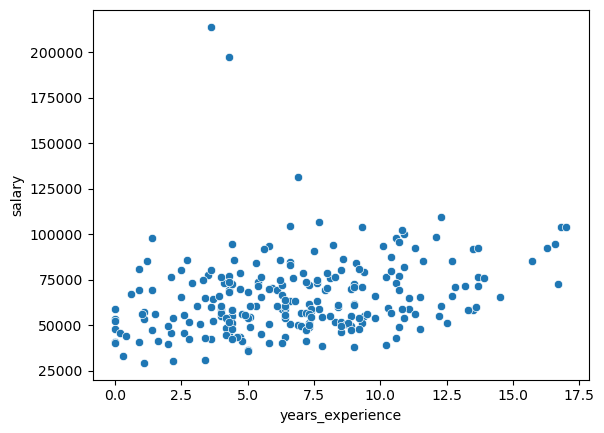

In [58]:
sns.scatterplot(x = df['years_experience'], y =  df['salary'])

**Exercise 2:** Compute the **covariance** and **Pearson correlation** between `years_experience` and `salary` using `cov()` and `corr()`.

In [54]:
print("Covariance :", df['years_experience'].cov(df['salary']))
print("Correlation :", df['years_experience'].corr(df['salary']))

Covariance : 21491.8156032078
Correlation : 0.2600928656337811


**Exercise 3:** Compute the **correlation matrix** for numeric columns `[salary, monthly_sales, years_experience, age, work_hours_per_week]` (drop NAs).

In [55]:
df_numeric.columns

Index(['id', 'years_experience', 'age', 'is_manager', 'work_hours_per_week',
       'performance_rating', 'salary', 'monthly_sales'],
      dtype='object')

In [56]:
df_numeric_updated = df_numeric[['years_experience', 'age', 'is_manager', 'work_hours_per_week',
       'performance_rating', 'salary', 'monthly_sales']]

df_numeric_updated.corr()

,years_experience,age,is_manager,work_hours_per_week,performance_rating,salary,monthly_sales
years_experience,1.000000,0.111958,0.029550,0.056071,0.067529,0.260093,-0.023867
age,0.111958,1.000000,-0.035370,0.091729,0.079456,0.058000,-0.182101
is_manager,0.029550,-0.035370,1.000000,0.041553,-0.139256,0.209631,-0.129701
work_hours_per_week,0.056071,0.091729,0.041553,1.000000,-0.040660,0.048585,-0.132204
performance_rating,0.067529,0.079456,-0.139256,-0.040660,1.000000,0.035789,0.087190
salary,0.260093,0.058000,0.209631,0.048585,0.035789,1.000000,-0.362455
monthly_sales,-0.023867,-0.182101,-0.129701,-0.132204,0.087190,-0.362455,1.000000


**Exercise 4:** Show one example each of **positive**, **negative**, and **near-zero** correlations from the matrix (if present). Write 1-line comments.

**Exercise 5:** **Correlation ≠ Causation:** in 1–2 lines, explain why a high correlation here does not guarantee a causal relationship.

In the month of may, the sale of icecream increases as well as the sales of sunglasses increases. Which means they have a positive correlation. But that does not mean that sale of icecream is causing the people to buy sunglasses. Hence correlation is not equal to causation.

# Cross-tabulations & Stacked Bar Charts; Numeric vs Categorical

**Exercise 1:** Create a **cross-tabulation** of `department` vs `region` and display counts.

In [57]:
pd.crosstab(df['department'], df['region']).reset_index()

region,department,East,North,South,West
0,Finance,9,10,5,10
1,HR,5,9,6,7
2,Operations,4,7,11,12
3,Sales,15,21,26,19
4,Tech,16,11,19,18


**Exercise 2:** Plot the cross-tab above as a **stacked bar chart** (counts).

<Axes: xlabel='department'>

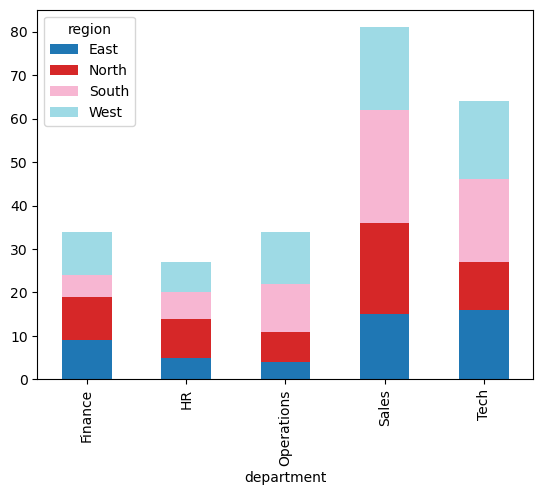

In [75]:
cross_tab = pd.crosstab(df['department'], df['region'])

cross_tab.plot(kind='bar', stacked=True, colormap='tab20')

**Exercise 3:** Create a normalized cross-tab (row-wise proportions) for `gender` vs `education_level` and plot as a stacked bar chart.

<Axes: xlabel='education_level'>

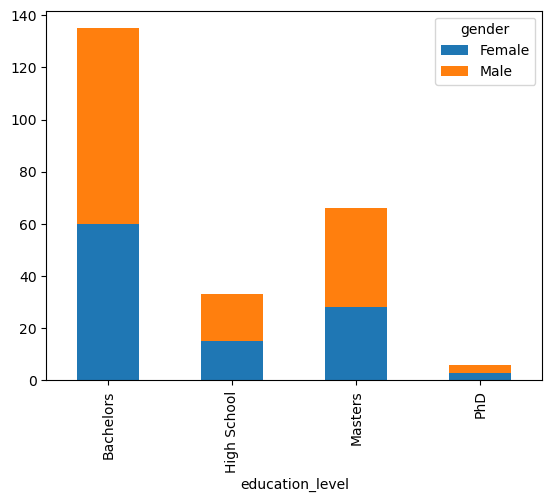

In [64]:
pd.crosstab(df['education_level'], df['gender']).plot(kind='bar', stacked=True)

**Exercise 4:** Numeric vs Categorical: compute **mean salary by department** and visualize with a **bar chart**.

<Axes: xlabel='department'>

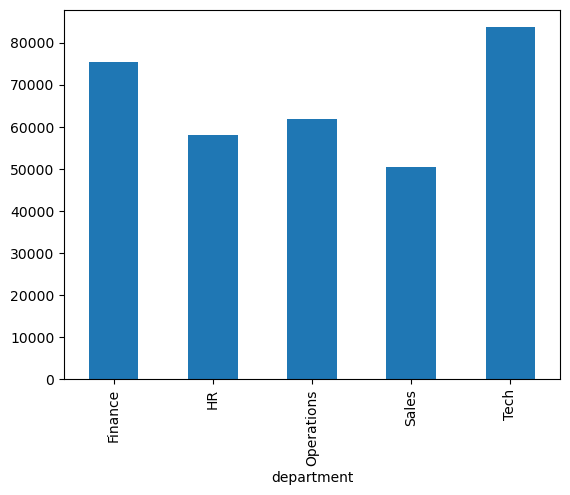

In [65]:
df.groupby('department')['salary'].mean().plot(kind='bar')

**Exercise 5:** Numeric vs Categorical: make a **box plot** of `monthly_sales` by `department` to compare distributions across groups.

<Axes: title={'center': 'monthly_sales'}, xlabel='department'>

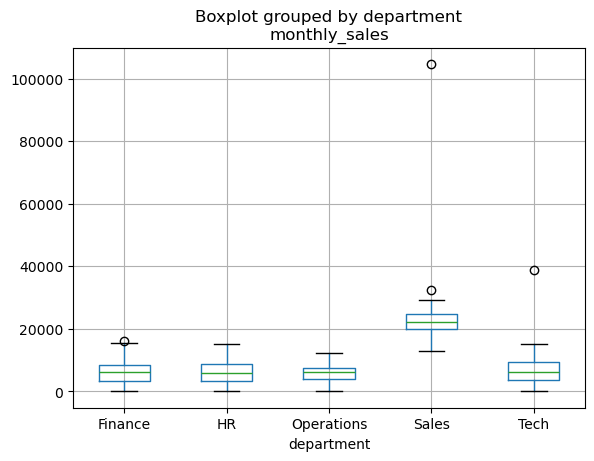

In [66]:
df.boxplot(column = 'monthly_sales', by = 'department')